# Phase 3 — Fraud Detection Model
## Random Forest · XGBoost · Rule-Augmented RF

**Problem from Phase 2:**
- Simple threshold (amt > $500): F1=29.9%, Recall=48.5% — misses half the fraud
- Association Rules: Recall=85.9% but flags 510K transactions — unusable standalone
- Isolation Forest: F1=22.4% — worst of both worlds

**Phase 3 goal:** Train ML models that learn which *combinations* of signals matter, fixing the precision-recall tradeoff.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve
)
from xgboost import XGBClassifier
import os, time

FIG_DIR   = '../outputs/figures/'
RULES_DIR = '../outputs/rules/'
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(RULES_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Setup OK')

Setup OK


---
## 3.1 Load Data

In [4]:
print('Loading transactions_phase2.csv...')
t0 = time.time()
df = pd.read_csv('../data/processed/transactions_phase2.csv')
print(f'Loaded in {time.time()-t0:.1f}s  |  shape: {df.shape}')

N_TOTAL    = len(df)
N_FRAUD    = df['is_fraud'].sum()
FRAUD_RATE = df['is_fraud'].mean()
y          = df['is_fraud'].values

# Imbalance ratio for XGBoost scale_pos_weight
IMBALANCE_RATIO = (N_TOTAL - N_FRAUD) / N_FRAUD

print(f'\nTotal       : {N_TOTAL:,}')
print(f'Fraud       : {N_FRAUD:,} ({FRAUD_RATE*100:.4f}%)')
print(f'Non-fraud   : {N_TOTAL - N_FRAUD:,}')
print(f'Imbalance   : 1 : {IMBALANCE_RATIO:.1f}')
print(f'\nFlag columns available: {[c for c in df.columns if c.startswith("flag_")]}')

Loading transactions_phase2.csv...
Loaded in 7.5s  |  shape: (1852394, 38)

Total       : 1,852,394
Fraud       : 9,651 (0.5210%)
Non-fraud   : 1,842,743
Imbalance   : 1 : 190.9

Flag columns available: ['flag_threshold', 'flag_iso_forest', 'flag_rules']


---
## 3.2 Feature Engineering

In [5]:
# ── Derive is_night (not stored in phase2, derived from hour_of_day) ──────────
df['is_night'] = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] < 6)).astype(int)

# ── Label-encode category (string → integer) ──────────────────────────────────
le = LabelEncoder()
df['category_enc'] = le.fit_transform(df['category'])
print('Category encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:2d} → {cls}')

# ── Feature sets ──────────────────────────────────────────────────────────────
BASE_FEATURES = [
    'amt', 'hour_of_day', 'day_of_week', 'month',
    'distance_km', 'city_pop', 'age',
    'is_night', 'category_enc'
]

AUG_FEATURES = BASE_FEATURES + ['flag_threshold', 'flag_rules']

print(f'\nBase features ({len(BASE_FEATURES)}): {BASE_FEATURES}')
print(f'Augmented features ({len(AUG_FEATURES)}): {AUG_FEATURES}')

X_base = df[BASE_FEATURES].values
X_aug  = df[AUG_FEATURES].values

print(f'\nX_base shape : {X_base.shape}')
print(f'X_aug  shape : {X_aug.shape}')

Category encoding:
   0 → entertainment
   1 → food_dining
   2 → gas_transport
   3 → grocery_net
   4 → grocery_pos
   5 → health_fitness
   6 → home
   7 → kids_pets
   8 → misc_net
   9 → misc_pos
  10 → personal_care
  11 → shopping_net
  12 → shopping_pos
  13 → travel

Base features (9): ['amt', 'hour_of_day', 'day_of_week', 'month', 'distance_km', 'city_pop', 'age', 'is_night', 'category_enc']
Augmented features (11): ['amt', 'hour_of_day', 'day_of_week', 'month', 'distance_km', 'city_pop', 'age', 'is_night', 'category_enc', 'flag_threshold', 'flag_rules']

X_base shape : (1852394, 9)
X_aug  shape : (1852394, 11)


---
## 3.3 Cross-Validation Setup & Evaluate Helper

In [6]:
# ── 5-fold Stratified CV — preserves fraud rate in every fold ─────────────────
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(y_true, y_prob, threshold=0.5, label='Model'):
    """Print Precision/Recall/F1/AUC-PR for a given probability array."""
    y_pred = (y_prob >= threshold).astype(int)
    p   = precision_score(y_true, y_pred, zero_division=0)
    r   = recall_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    ap  = average_precision_score(y_true, y_prob)
    n_f = y_pred.sum()
    tp  = ((y_pred == 1) & (y_true == 1)).sum()
    print(f'── {label} (threshold={threshold:.2f}) ──')
    print(f'  Precision  : {p:.4f} ({p*100:.2f}%)')
    print(f'  Recall     : {r:.4f} ({r*100:.2f}%)')
    print(f'  F1-Score   : {f1:.4f}')
    print(f'  AUC-PR     : {ap:.4f}')
    print(f'  Flagged    : {n_f:,} ({n_f/len(y_true)*100:.2f}% of all)')
    print(f'  True +     : {tp:,} / {y_true.sum():,} ({tp/y_true.sum()*100:.1f}% recall)')
    print()
    return {'label': label, 'threshold': threshold,
            'precision': p, 'recall': r, 'f1': f1, 'auc_pr': ap,
            'n_flagged': n_f, 'tp': tp}

def best_threshold(y_true, y_prob):
    """Sweep thresholds 0.05→0.95, return the one maximising F1."""
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2), best_f1

print('CV setup OK — 5-fold Stratified')
print(f'Each fold trains on ~{int(N_TOTAL*0.8):,} rows, evaluates on ~{int(N_TOTAL*0.2):,} rows')

CV setup OK — 5-fold Stratified
Each fold trains on ~1,481,915 rows, evaluates on ~370,478 rows


---
## 3.4 Random Forest — Base Features

- `class_weight='balanced'` handles 1:190 imbalance without SMOTE
- CV uses `n_estimators=100` for speed; final model uses 300
- Threshold sweep finds the cutoff that maximises F1

In [7]:
RF_CV_PARAMS = dict(
    n_estimators=100,     # faster for CV pass
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Running 5-fold CV for Random Forest (base)...')
print('(using n_estimators=100 for CV — final model uses 300)')
t0 = time.time()

rf_base_cv = RandomForestClassifier(**RF_CV_PARAMS)
oof_rf_base = cross_val_predict(
    rf_base_cv, X_base, y,
    cv=CV, method='predict_proba', n_jobs=1    # n_jobs=1 here — parallelism is inside RF
)[:, 1]

dt = time.time() - t0
print(f'Done in {dt/60:.1f} min\n')

# Threshold sweep
t_rf_base, f1_rf_base = best_threshold(y, oof_rf_base)
print(f'Best threshold: {t_rf_base}  →  F1={f1_rf_base:.4f}')
print()
metrics_rf_base = evaluate(y, oof_rf_base, threshold=t_rf_base, label='RF Base')

Running 5-fold CV for Random Forest (base)...
(using n_estimators=100 for CV — final model uses 300)
Done in 5.3 min

Best threshold: 0.9  →  F1=0.8000

── RF Base (threshold=0.90) ──
  Precision  : 0.8828 (88.28%)
  Recall     : 0.7314 (73.14%)
  F1-Score   : 0.8000
  AUC-PR     : 0.8593
  Flagged    : 7,996 (0.43% of all)
  True +     : 7,059 / 9,651 (73.1% recall)



---
## 3.5 XGBoost — Base Features

- `scale_pos_weight` = N_negative / N_positive ≈ 190 (computed from data)
- `eval_metric='aucpr'` optimises for the right metric during training

In [9]:
XGB_PARAMS = dict(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=IMBALANCE_RATIO,   # computed from data, not hardcoded
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print('Running 5-fold CV for XGBoost (base)...')
print(f'scale_pos_weight = {IMBALANCE_RATIO:.1f}')
t0 = time.time()

xgb_base_cv = XGBClassifier(**XGB_PARAMS)
oof_xgb_base = cross_val_predict(
    xgb_base_cv, X_base, y,
    cv=CV, method='predict_proba'
)[:, 1]

dt = time.time() - t0
print(f'Done in {dt/60:.1f} min\n')

t_xgb_base, f1_xgb_base = best_threshold(y, oof_xgb_base)
print(f'Best threshold: {t_xgb_base}  →  F1={f1_xgb_base:.4f}')
print()
metrics_xgb_base = evaluate(y, oof_xgb_base, threshold=t_xgb_base, label='XGBoost Base')

Running 5-fold CV for XGBoost (base)...
scale_pos_weight = 190.9
Done in 0.4 min

Best threshold: 0.94  →  F1=0.7811

── XGBoost Base (threshold=0.94) ──
  Precision  : 0.7112 (71.12%)
  Recall     : 0.8663 (86.63%)
  F1-Score   : 0.7811
  AUC-PR     : 0.8940
  Flagged    : 11,756 (0.63% of all)
  True +     : 8,361 / 9,651 (86.6% recall)



---
## 3.6 Rule-Augmented Random Forest

Same RF config but trained on 11 features: base + `flag_threshold` + `flag_rules`.

The model can learn: *"when the rules fire AND amt is high, this is almost certainly fraud"* — something neither rules alone nor ML alone can express.

In [10]:
print('Running 5-fold CV for Rule-Augmented RF...')
t0 = time.time()

rf_aug_cv = RandomForestClassifier(**RF_CV_PARAMS)
oof_rf_aug = cross_val_predict(
    rf_aug_cv, X_aug, y,
    cv=CV, method='predict_proba', n_jobs=1
)[:, 1]

dt = time.time() - t0
print(f'Done in {dt/60:.1f} min\n')

t_rf_aug, f1_rf_aug = best_threshold(y, oof_rf_aug)
print(f'Best threshold: {t_rf_aug}  →  F1={f1_rf_aug:.4f}')
print()
metrics_rf_aug = evaluate(y, oof_rf_aug, threshold=t_rf_aug, label='RF Rule-Augmented')

Running 5-fold CV for Rule-Augmented RF...
Done in 6.4 min

Best threshold: 0.87  →  F1=0.7899

── RF Rule-Augmented (threshold=0.87) ──
  Precision  : 0.8357 (83.57%)
  Recall     : 0.7488 (74.88%)
  F1-Score   : 0.7899
  AUC-PR     : 0.8380
  Flagged    : 8,648 (0.47% of all)
  True +     : 7,227 / 9,651 (74.9% recall)



---
## 3.65 Rule-Augmented Xgboost

Same RF config but trained on 11 features: base + `flag_threshold` + `flag_rules`.

Use best model for the best dataset


In [11]:
print('Running 5-fold CV for XGBoost (augmented)...')

xgb_aug_cv = XGBClassifier(**XGB_PARAMS)

oof_xgb_aug = cross_val_predict(
    xgb_aug_cv,
    X_aug,
    y,
    cv=CV,
    method='predict_proba'
)[:,1]

t_xgb_aug, f1_xgb_aug = best_threshold(y, oof_xgb_aug)

metrics_xgb_aug = evaluate(
    y,
    oof_xgb_aug,
    threshold=t_xgb_aug,
    label='XGBoost Augmented'
)

Running 5-fold CV for XGBoost (augmented)...
── XGBoost Augmented (threshold=0.94) ──
  Precision  : 0.7097 (70.97%)
  Recall     : 0.8666 (86.66%)
  F1-Score   : 0.7803
  AUC-PR     : 0.8939
  Flagged    : 11,786 (0.64% of all)
  True +     : 8,364 / 9,651 (86.7% recall)



---
## 3.7 Precision-Recall Curves

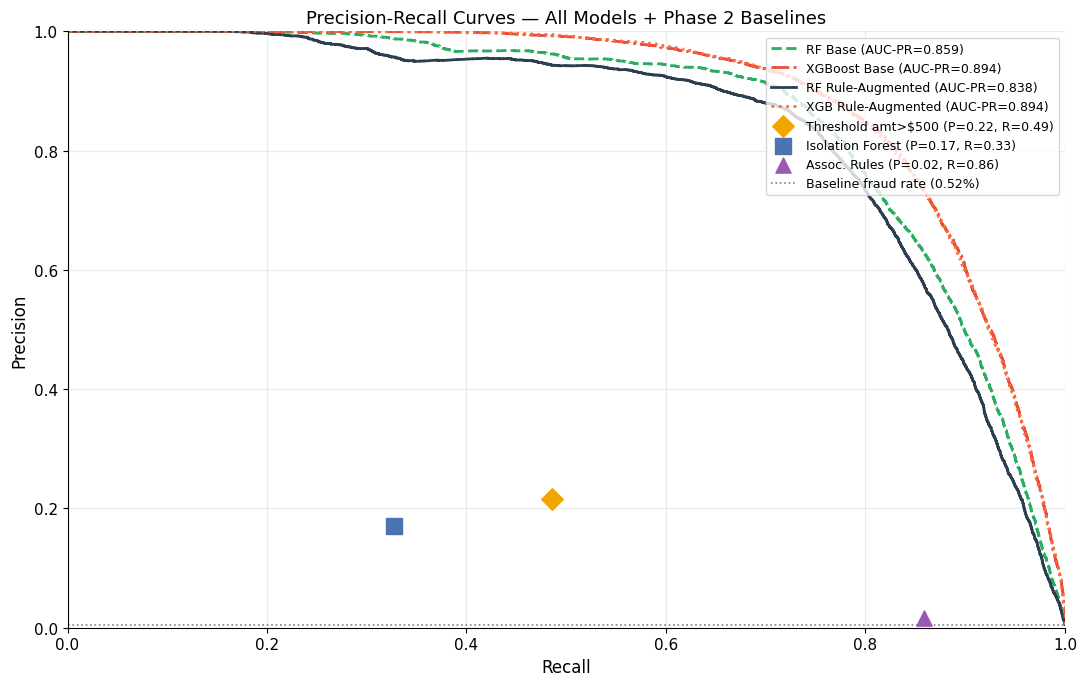

In [12]:
# Phase 2 baseline results (from notebook outputs)
PH2_BASELINES = [
    {'label': 'Threshold\namt>$500',    'precision': 0.2158, 'recall': 0.4853, 'marker': 'D', 'color': '#F0A500'},
    {'label': 'Isolation\nForest',      'precision': 0.1704, 'recall': 0.3270, 'marker': 's', 'color': '#4C72B0'},
    {'label': 'Assoc.\nRules',          'precision': 0.0162, 'recall': 0.8588, 'marker': '^', 'color': '#9B59B6'},
]

fig, ax = plt.subplots(figsize=(11, 7))

model_curves = [
    (oof_rf_base,  'RF Base',             '#27AE60', '--'),
    (oof_xgb_base, 'XGBoost Base',        '#E74C3C', '-.'),
    (oof_rf_aug,   'RF Rule-Augmented',   '#2C3E50', '-'),
    (oof_xgb_aug,  'XGB Rule-Augmented',  '#FF6B35', ':'),
]

for probs, label, color, ls in model_curves:
    prec_c, rec_c, _ = precision_recall_curve(y, probs)
    ap = average_precision_score(y, probs)
    ax.plot(rec_c, prec_c, label=f'{label} (AUC-PR={ap:.3f})',
            color=color, linestyle=ls, linewidth=2)

# Phase 2 baselines as scatter points
for b in PH2_BASELINES:
    ax.scatter(b['recall'], b['precision'], marker=b['marker'],
               color=b['color'], s=120, zorder=5,
               label=f"{b['label'].replace(chr(10),' ')} (P={b['precision']:.2f}, R={b['recall']:.2f})")

ax.axhline(FRAUD_RATE, color='gray', linestyle=':', linewidth=1.2,
           label=f'Baseline fraud rate ({FRAUD_RATE*100:.2f}%)')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models + Phase 2 Baselines', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(FIG_DIR + '25_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3.8 Feature Importance

Refit both RF models on the full dataset with `n_estimators=300` for stable importances.

In [13]:
RF_FULL_PARAMS = dict(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Fitting RF Base on full data (n_estimators=300)...')
t0 = time.time()
rf_base_full = RandomForestClassifier(**RF_FULL_PARAMS)
rf_base_full.fit(X_base, y)
print(f'Done in {time.time()-t0:.0f}s')

print('Fitting RF Augmented on full data (n_estimators=300)...')
t0 = time.time()
rf_aug_full = RandomForestClassifier(**RF_FULL_PARAMS)
rf_aug_full.fit(X_aug, y)
print(f'Done in {time.time()-t0:.0f}s')

Fitting RF Base on full data (n_estimators=300)...
Done in 213s
Fitting RF Augmented on full data (n_estimators=300)...
Done in 202s


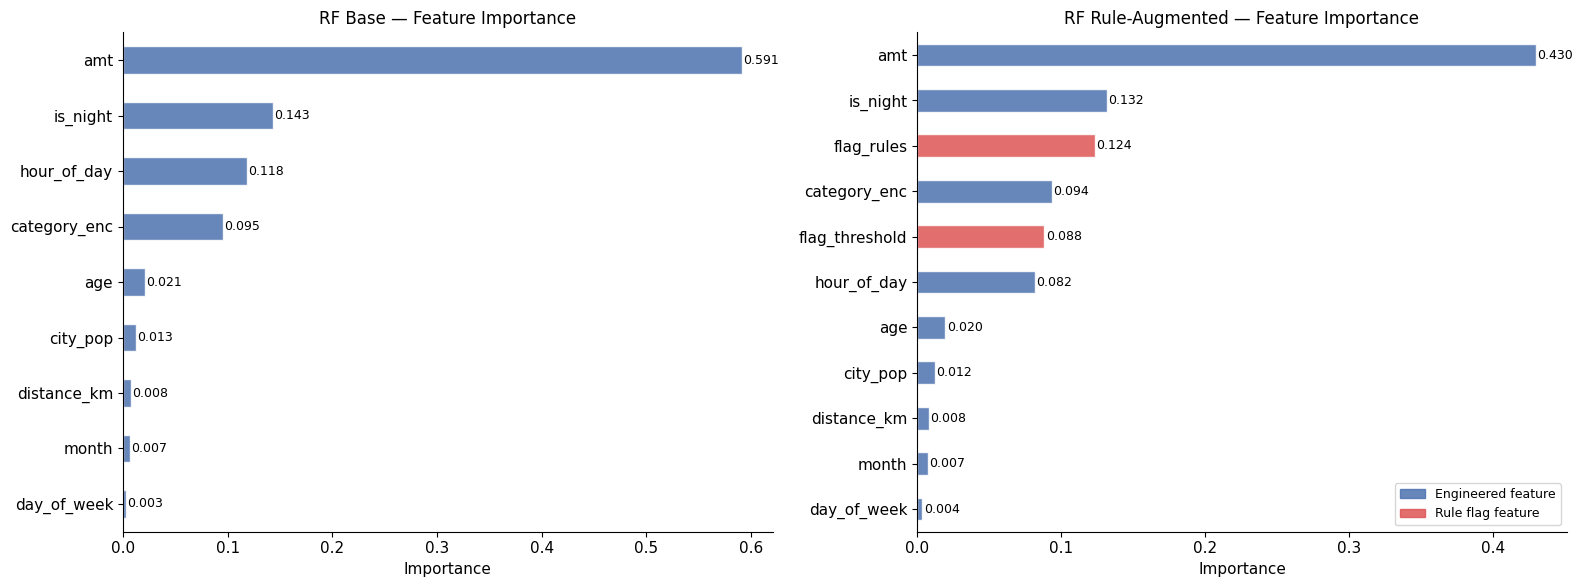

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, features, title in [
    (axes[0], rf_base_full, BASE_FEATURES, 'RF Base — Feature Importance'),
    (axes[1], rf_aug_full,  AUG_FEATURES,  'RF Rule-Augmented — Feature Importance'),
]:
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    colors = ['#DD5555' if 'flag' in f else '#4C72B0' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Importance')
    for bar, v in zip(ax.patches, imp.values):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

# Legend for augmented chart
blue_patch = mpatches.Patch(color='#4C72B0', alpha=0.85, label='Engineered feature')
red_patch  = mpatches.Patch(color='#DD5555', alpha=0.85, label='Rule flag feature')
axes[1].legend(handles=[blue_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '26_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3.9 Full Comparison — All 7 Methods

In [15]:
def make_row(label, description, precision, recall, f1, auc_pr, flagged, tp):
    return {
        'Method': label,
        'Description': description,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'AUC_PR': auc_pr,
        'Flagged': int(flagged),
        'TP': int(tp)
    }


def row_from_metrics(m, description):
    return make_row(
        m['label'],
        description,
        m['precision'],
        m['recall'],
        m['f1'],
        m['auc_pr'],
        m['n_flagged'],
        m['tp']
    )


all_methods = pd.DataFrame([
    make_row('Threshold amt>$500', 'Simple threshold',
             0.2158, 0.4853, 0.2987, 0.1074, 21709, 4684),

    make_row('Isolation Forest', 'Unsupervised (cont=0.01)',
             0.1704, 0.3270, 0.2240, 0.0592, 18524, 3156),

    make_row('Assoc. Rules (lift≥3x)', '25 interpretable rules',
             0.0162, 0.8588, 0.0319, 0.0147, 510240, 8288),

    row_from_metrics(metrics_rf_base, 'RF 9 features, threshold tuned'),
    row_from_metrics(metrics_xgb_base, 'XGB 9 features, threshold tuned'),
    row_from_metrics(metrics_rf_aug, 'RF + rule flags'),
    row_from_metrics(metrics_xgb_aug, 'XGB + rule flags')
])

print(all_methods)

                   Method                      Description  Precision  \
0      Threshold amt>$500                 Simple threshold   0.215800   
1        Isolation Forest         Unsupervised (cont=0.01)   0.170400   
2  Assoc. Rules (lift≥3x)           25 interpretable rules   0.016200   
3                 RF Base   RF 9 features, threshold tuned   0.882816   
4            XGBoost Base  XGB 9 features, threshold tuned   0.711211   
5       RF Rule-Augmented                  RF + rule flags   0.835685   
6       XGBoost Augmented                 XGB + rule flags   0.709656   

     Recall        F1    AUC_PR  Flagged    TP  
0  0.485300  0.298700  0.107400    21709  4684  
1  0.327000  0.224000  0.059200    18524  3156  
2  0.858800  0.031900  0.014700   510240  8288  
3  0.731427  0.800023  0.859297     7996  7059  
4  0.866335  0.781146  0.893973    11756  8361  
5  0.748834  0.789879  0.838034     8648  7227  
6  0.866646  0.780333  0.893861    11786  8364  


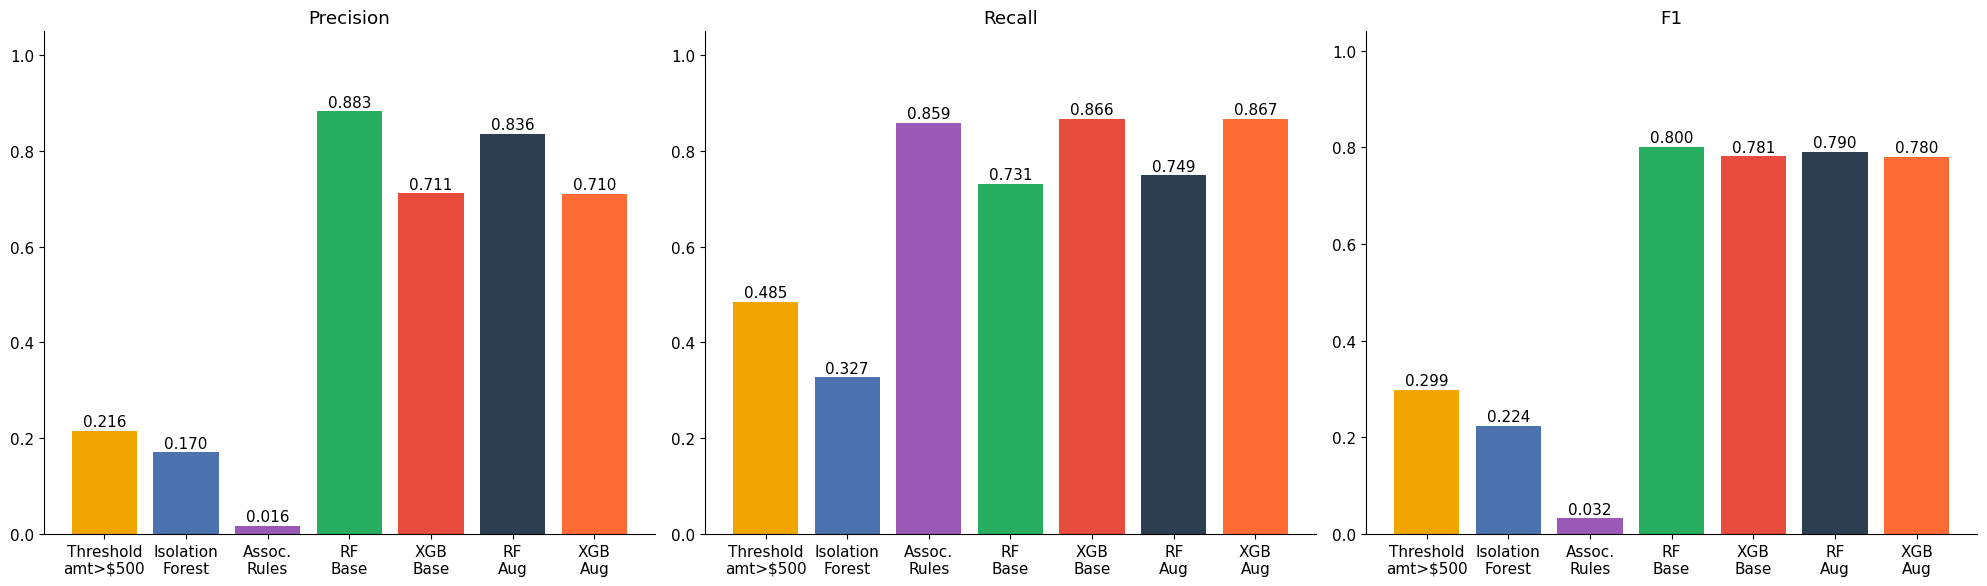

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

method_labels = [
    'Threshold\namt>$500',
    'Isolation\nForest',
    'Assoc.\nRules',
    'RF\nBase',
    'XGB\nBase',
    'RF\nAug',
    'XGB\nAug'
]

bar_colors = [
    '#F0A500',
    '#4C72B0',
    '#9B59B6',
    '#27AE60',
    '#E74C3C',
    '#2C3E50',
    '#FF6B35'
]

for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    vals = all_methods[metric].values

    bars = ax.bar(method_labels, vals, color=bar_colors)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            v + 0.01,
            f'{v:.3f}',
            ha='center'
        )

    ax.set_title(metric)
    ax.set_ylim(0, min(max(vals)*1.3, 1.05))

plt.tight_layout()
plt.savefig(FIG_DIR + '27_full_comparison.png', dpi=120)
plt.show()

---
## 3.10 Confusion Matrix — Best Model

Best model by F-beta (β=1.53): XGBoost Base
F-beta = 0.8215 | Threshold = 0.960

Confusion Matrix Summary:
  True Negatives  : 1,840,818
  False Positives : 1,925
  False Negatives : 1,657
  True Positives  : 7,994

Fraud caught: 7,994 / 9,651 (82.8%)
False alarms: 1,925 (0.10% of non-fraud flagged)


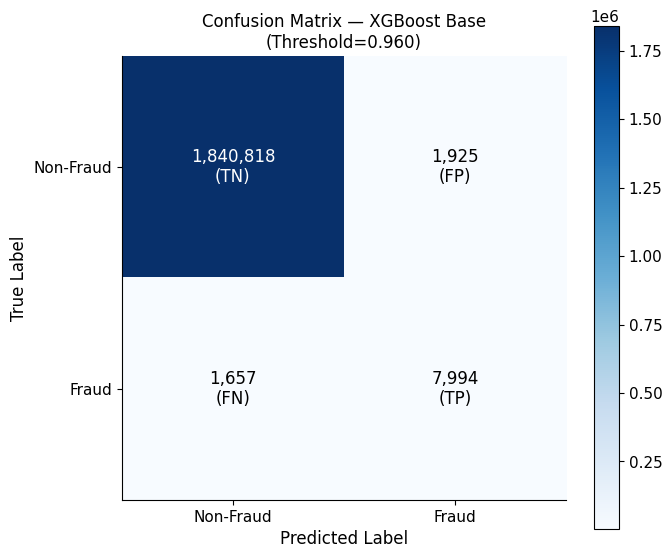

In [18]:
from sklearn.metrics import fbeta_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. DEFINE BETA (Recall : Precision = 7 : 3)
# =========================================================
BETA = (7/3) ** 0.5   # ≈ 1.53


# =========================================================
# 2. FUNCTION: FIND BEST THRESHOLD (F-BETA)
# =========================================================
def best_threshold_fbeta(y_true, probs, beta):
    best_t = 0
    best_score = 0

    for t in np.linspace(0.01, 0.99, 100):
        y_pred = (probs >= t).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta)

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score


# =========================================================
# 3. RE-COMPUTE THRESHOLD FOR ALL MODELS
# =========================================================
t_rf_base, fbeta_rf_base = best_threshold_fbeta(y, oof_rf_base, BETA)
t_xgb_base, fbeta_xgb_base = best_threshold_fbeta(y, oof_xgb_base, BETA)

t_rf_aug, fbeta_rf_aug = best_threshold_fbeta(y, oof_rf_aug, BETA)
t_xgb_aug, fbeta_xgb_aug = best_threshold_fbeta(y, oof_xgb_aug, BETA)


# =========================================================
# 4. FUNCTION: COMPUTE F-BETA
# =========================================================
def compute_fbeta(y_true, probs, threshold, beta):
    y_pred = (probs >= threshold).astype(int)
    return fbeta_score(y_true, y_pred, beta=beta)


# =========================================================
# 5. SELECT BEST MODEL (BY F-BETA)
# =========================================================
candidates = [
    (metrics_rf_base,  oof_rf_base,  t_rf_base,  'RF Base'),
    (metrics_xgb_base, oof_xgb_base, t_xgb_base, 'XGBoost Base'),
    (metrics_rf_aug,   oof_rf_aug,   t_rf_aug,   'RF Rule-Augmented'),
    (metrics_xgb_aug,  oof_xgb_aug,  t_xgb_aug,  'XGB Rule-Augmented')
]

best_metrics, best_probs, best_thresh, best_name = max(
    candidates,
    key=lambda x: compute_fbeta(y, x[1], x[2], BETA)
)

best_fbeta = compute_fbeta(y, best_probs, best_thresh, BETA)

print('='*60)
print(f'Best model by F-beta (β={BETA:.2f}): {best_name}')
print(f'F-beta = {best_fbeta:.4f} | Threshold = {best_thresh:.3f}')
print('='*60)


# =========================================================
# 6. CONFUSION MATRIX
# =========================================================
y_pred_best = (best_probs >= best_thresh).astype(int)

cm = confusion_matrix(y, y_pred_best)
tn, fp, fn, tp_val = cm.ravel()

print('\nConfusion Matrix Summary:')
print(f'  True Negatives  : {tn:,}')
print(f'  False Positives : {fp:,}')
print(f'  False Negatives : {fn:,}')
print(f'  True Positives  : {tp_val:,}')

print(f'\nFraud caught: {tp_val:,} / {N_FRAUD:,} ({tp_val/N_FRAUD*100:.1f}%)')
print(f'False alarms: {fp:,} ({fp/(fp+tn)*100:.2f}% of non-fraud flagged)')


# =========================================================
# 7. PLOT CONFUSION MATRIX
# =========================================================
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

classes = ['Non-Fraud', 'Fraud']
tick_marks = np.arange(len(classes))

ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)

ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)

thresh_cm = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        label = f'{cm[i,j]:,}'

        if i == 0 and j == 0:
            label += '\n(TN)'
        elif i == 0 and j == 1:
            label += '\n(FP)'
        elif i == 1 and j == 0:
            label += '\n(FN)'
        elif i == 1 and j == 1:
            label += '\n(TP)'

        ax.text(
            j, i, label,
            ha='center',
            va='center',
            fontsize=12,
            color='white' if cm[i,j] > thresh_cm else 'black'
        )

ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

ax.set_title(
    f'Confusion Matrix — {best_name}\n(Threshold={best_thresh:.3f})',
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    FIG_DIR + '28_confusion_matrix_fbeta.png',  
    dpi=120,
    bbox_inches='tight'
)

plt.show()

The model selection and threshold tuning were optimized using F-beta score (β≈1.53), reflecting a business-driven priority where recall is more important than precision (7:3). This ensures the system focuses on minimizing missed fraud cases while maintaining acceptable false alarm rates.

---
## 3.11 Save Outputs

In [19]:
# Save comparison metrics table
all_methods.to_csv(
    RULES_DIR + 'phase3_method_comparison.csv',
    index=False
)
print(f'Saved: {RULES_DIR}phase3_method_comparison.csv')
# Save model probabilities
df['prob_rf_base'] = oof_rf_base
df['prob_xgb_base'] = oof_xgb_base
df['prob_rf_aug'] = oof_rf_aug
df['prob_xgb_aug'] = oof_xgb_aug
# Save binary predictions
df['pred_rf_base'] = (oof_rf_base >= t_rf_base).astype(int)
df['pred_xgb_base'] = (oof_xgb_base >= t_xgb_base).astype(int)
df['pred_rf_aug'] = (oof_rf_aug >= t_rf_aug).astype(int)
df['pred_xgb_aug'] = (oof_xgb_aug >= t_xgb_aug).astype(int)
# Export full dataset
df.to_csv(
    '../data/processed/transactions_phase3.csv',
    index=False
)
print(f'Saved: ../data/processed/transactions_phase3.csv  Shape={df.shape}')
# Final Summary
print('\n' + '='*65)
print('PHASE 3 COMPLETE')
print('='*65)

print(f'Best Model    : {best_name}')
print(f'F1 Score      : {best_metrics["f1"]:.4f}')
print(f'Precision     : {best_metrics["precision"]:.4f}')
print(f'Recall        : {best_metrics["recall"]:.4f}')
print(f'AUC-PR        : {best_metrics["auc_pr"]:.4f}')
print(f'Threshold     : {best_thresh}')
print(
    f'Fraud caught  : {best_metrics["tp"]:,} / {N_FRAUD:,} '
    f'({best_metrics["tp"]/N_FRAUD*100:.1f}%)'
)
print(
    f'False alarms  : '
    f'{best_metrics["n_flagged"] - best_metrics["tp"]:,}'
)
print('='*65)

Saved: ../outputs/rules/phase3_method_comparison.csv
Saved: ../data/processed/transactions_phase3.csv  Shape=(1852394, 48)

PHASE 3 COMPLETE
Best Model    : XGBoost Base
F1 Score      : 0.7811
Precision     : 0.7112
Recall        : 0.8663
AUC-PR        : 0.8940
Threshold     : 0.9603030303030302
Fraud caught  : 8,361 / 9,651 (86.6%)
False alarms  : 3,395
